In [10]:
import torch
import os
from utilities import *
device = torch.device('xpu')
print(device)

xpu


In [24]:
# Parameters

ranges = [-1, 1]
n_test = 1000
steps = 200
grids = [3, 5, 10, 20, 50, 100]
k=3
lr=1
seeds = [42, 0, 1]
target_r2 = 0.95
increment = 100
# dimensions = [90, 95, 100]
dimensions = list(range(5, 101, 5))

In [21]:
def find_N_binary(d, data, type, seed, target_r2=target_r2, min_samples=10, tolerance=10):

    dataset_path = os.path.join("datasets", f"seed {seed}", f"{data}_dataset_dim{d}_seed{seed}_big.pt")
    if not os.path.exists(dataset_path):
        dataset = generate_dataset(dim=d, seed=seed, data=data, n_train=2000, n_test=n_test)
    else:
        dataset = torch.load(dataset_path, map_location=torch.device('cpu'))
    total = dataset['train_input'].shape[0]
    low = min_samples
    high = total
    best = None
    last_result = None

    while low <= high:
        if (high - low) <= tolerance:
            break
        
        mid = (low + high) // 2
        if mid < min_samples:
            mid = min_samples

        sliced_dataset = {
            'train_input': dataset['train_input'][:mid],
            'train_label': dataset['train_label'][:mid],
            'test_input': dataset['test_input'],
            'test_label': dataset['test_label']
        }

        print(low, high, mid)

        width = [d, 1, 1]
        if type == "static":
            result = train_kan(dataset=sliced_dataset, width=width, k=k, lr=lr, steps=steps, seed=seed, grids=grids, static=True, target_r2=target_r2)
        elif type == "dynamic":
            result = train_kan(dataset=sliced_dataset, width=width, k=k, lr=lr, steps=steps, seed=seed, grids=grids, static=False, target_r2=target_r2)
        else:
            mlp_hidden_width = math.ceil((10*d+11)/(d+2)) - 1
            print(low, high)
            result = train_mlp(width=[d, mlp_hidden_width, 1], dataset=sliced_dataset, seed=seed, steps=steps, lr=lr)

        last_result = result
        achieved = result['r2s'][-1]
        if achieved >= target_r2:
            best = mid
            high = mid - 1
        else:
            low = mid + 1

    output_dir = os.path.join("2-results-C", f"seed {seed}")
    os.makedirs(output_dir, exist_ok=True)

    if best is not None:
        interval = (min(low, high), max(low, high))
        torch.save({'interval': interval, 'last_result': last_result}, os.path.join(output_dir, f"{type}_{data}_result_dim{d}_seed{seed}_interval.pt"))
        return interval, last_result
    else:
        torch.save({'interval': None, 'last_result': last_result}, os.path.join(output_dir, f"{type}_{data}_result_dim{d}_seed{seed}_interval.pt"))
        return None, last_result

In [22]:
N_results_static = {}
N_results_dynamic = {}

for seed in seeds:
    N_results_static[seed] = {}
    N_results_dynamic[seed] = {}
    for d in dimensions:
        print(f"Searching N for data=C, dim={d} (static)")
        N_static, res_static = find_N_binary(d, 'C', 'static', seed)
        N_results_static[seed][d] = {'N': N_static, 'result': res_static}

        print(f"Searching N for data=C, dim={d} (dynamic)")
        N_dyn, res_dyn = find_N_binary(d, 'C', 'dynamic', seed)
        N_results_dynamic[seed][d] = {'N': N_dyn, 'result': res_dyn}

Searching N for data=C, dim=5 (static)
10 2000 1005


Grid=3:   0%|          | 0/200 [00:00<?, ?it/s]

Target R2 of 0.95 reached at step 0. N=1005
10 1004 507


Target R2 of 0.95 reached at step 0. N=507
10 506 258


Target R2 of 0.95 reached at step 0. N=258
10 257 133


...

Target R2 of 0.95 reached at step 1. N=258
10 257 133


Target R2 of 0.95 reached at step 2. N=133
10 132 71


72 132 102


103 132 117


Target R2 of 0.95 reached at step 2. N=117
103 116 109


In [83]:
seeds = [0, 1, 42]

5 [17, 17, 17] [23, 23, 23]
10 [25, 48, 25] [31, 54, 31]
15 [41, 41, 41] [46, 46, 46]
20 [41, 48, 56] [46, 54, 62]
25 [72, 64, 48] [77, 70, 54]
30 [64, 72, 79] [70, 77, 85]
35 [95, 87, 79] [101, 93, 85]
40 [118, 95, 87] [124, 101, 93]
45 [103, 110, 103] [108, 116, 108]
50 [118, 126, 110] [124, 132, 116]
55 [144, 136, 121] [149, 142, 127]
60 [136, 159, 136] [142, 164, 142]
65 [159, 159, 166] [164, 164, 171]
70 [159, 151, 151] [164, 157, 157]
75 [180, 173, 195] [186, 178, 201]
80 [173, 173, 210] [178, 178, 216]
85 [210, 195, 195] [216, 201, 201]
90 [218, 210, 225] [223, 216, 230]
95 [225, 292, 225] [230, 297, 230]
100 [239, 203, 247] [245, 208, 252]
5 [17, 17, 17] [23, 23, 23]
10 [25, 48, 25] [31, 54, 31]
15 [41, 41, 41] [46, 46, 46]
20 [41, 48, 56] [46, 54, 62]
25 [72, 64, 48] [77, 70, 54]
30 [64, 72, 79] [70, 77, 85]
35 [95, 87, 79] [101, 93, 85]
40 [118, 95, 87] [124, 101, 93]
45 [103, 110, 103] [108, 116, 108]
50 [118, 126, 110] [124, 132, 116]
55 [144, 136, 121] [149, 142, 127]
60 [

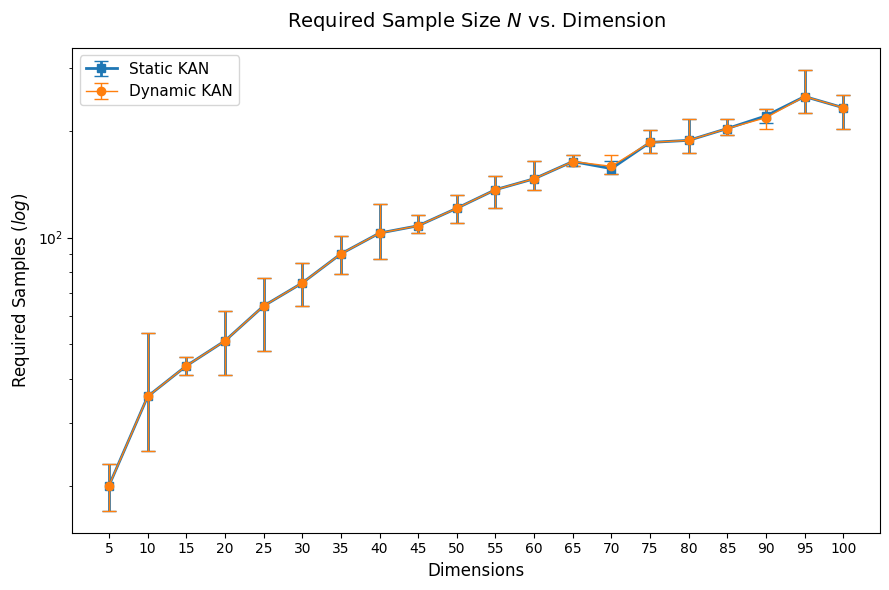

In [25]:
def process_kan_data(kan_type, dimensions, seeds):
    """
    Processes intervals for either 'static' or 'dynamic' KAN 
    and returns plotting coordinates and errors.
    """
    plot_dimensions = []
    required_N = []
    error_lower = []
    error_upper = []

    for d in dimensions:
        dim_lows = []
        dim_highs = []
        
        for seed in seeds:
            # Dynamically switch between static_A and dynamic_A filenames
            file_name = f"{kan_type}_C_result_dim{d}_seed{seed}_interval.pt"
            file_path = os.path.join("2-results-C", f"seed {seed}", file_name)
            
            if os.path.exists(file_path):
                result = torch.load(file_path)['interval']
            else:
                result = None
                
            if result is None:
                result = (1000000, 1000000)
                
            if isinstance(result, tuple):
                low, high = result
            else:
                low, high = result, result
                
            dim_lows.append(low)
            dim_highs.append(high)
        
        # Absolute min/max across all seeds
        print(d, dim_lows, dim_highs)
        absolute_min = min(dim_lows)
        absolute_max = max(dim_highs)
        
        # Calculate center point (mean of midpoints)
        mid_points = [(l + h) / 2 for l, h in zip(dim_lows, dim_highs)]
        center_point = np.mean(mid_points) 
        
        plot_dimensions.append(d)
        required_N.append(center_point)
        error_lower.append(max(0, center_point - absolute_min))
        error_upper.append(max(0, absolute_max - center_point))
        
    return plot_dimensions, required_N, [error_lower, error_upper]

# 1. Extract data for both models
dims_static, log_N_static, yerr_static = process_kan_data("static", dimensions, seeds)
dims_dynamic, log_N_dynamic, yerr_dynamic = process_kan_data("dynamic", dimensions, seeds)

# 2. Create the plot
plt.figure(figsize=(9, 6))

# Plot Static KAN (Blue)
plt.errorbar(
    dims_static, 
    log_N_static, 
    yerr=yerr_static, 
    fmt='-s',          
    capsize=5,         
    color='#1f77b4',   
    linewidth=2, 
    markersize=6, 
    label="Static KAN"
)

# Plot Dynamic KAN (Orange/Coral)
plt.errorbar(
    dims_dynamic, 
    log_N_dynamic, 
    yerr=yerr_dynamic, 
    fmt='-o',          # Square markers 's' to visually distinguish from circles
    capsize=5,         
    color='#ff7f0e',   # Clean orange color
    linewidth=1, 
    markersize=6, 
    label="Dynamic KAN"
)

# 3. Customize labels and styling
plt.xlabel("Dimensions", fontsize=12)
plt.ylabel("Required Samples ($log$)", fontsize=12)
plt.title("Required Sample Size $N$ vs. Dimension", fontsize=14, pad=15)
plt.yscale('log')

plt.xticks(dimensions)  
# plt.grid(True, linestyle='--', alpha=0.5, which="both") 
plt.legend(fontsize=11)

# Display the plot
plt.tight_layout()
plt.savefig(f"2-result.png", bbox_inches='tight', dpi=300)
plt.show()

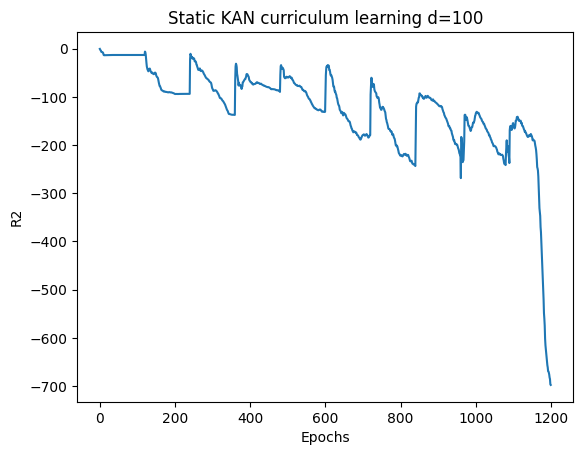

In [8]:
import matplotlib.pyplot as plt
plt.plot(static_kan_A['r2s'])
plt.title("Static KAN curriculum learning d=100")
plt.xlabel("Epochs")
plt.ylabel("R2")
plt.show()

In [67]:
load = torch.load("2-results/seed 42/static_A_result_dim100_seed42_interval.pt", weights_only=False)
print(load['interval'])

(1000, 1068)
